In [ ]:
#Trenowanie modelu SVM na cechach HOG
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

#KONFIGURACJA
data_dir = '../data/selected_signs'
IMG_SIZE = (64, 64) # Ujednolicony rozmiar dla wszystkich zdjęć

X = [] # Wektory cech HOG
y = [] # Etykiety (nazwy klas)

print("Przetwarzanie zdjęć i ekstrakcja HOG...")

# Przechodzimy przez każdy folder
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            
            # Wczytanie obrazu
            img = cv2.imread(img_path)
            if img is not None:
                # 1. Zmiana rozmiaru
                img_resized = cv2.resize(img, IMG_SIZE)
                
                # 2. Konwersja do skali szarości
                gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
                
                # 3. Ekstrakcja cech HOG
                features = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                               cells_per_block=(2, 2), block_norm='L2-Hys',
                               visualize=False)
                
                X.append(features)
                y.append(class_name)

# Konwersja do tablic numpy dla scikit-learn
X = np.array(X)
y = np.array(y)

print(f"Przetworzono {len(X)} zdjęć.")
print(f"Długość pojedynczego wektora HOG: {X.shape[1]}")

#TRENING MODELU
print("\nDzielenie danych na zbiór treningowy (80%) i testowy (20%)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Trenuję klasyfikator SVM...")
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train, y_train)

#EWALUACJA
print("Testuję model...")
y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nOgólna skuteczność modelu: {accuracy * 100:.2f}%\n")

print("Raport klasyfikacji:")
print(classification_report(y_test, y_pred))

Całkowita liczba wygenerowanych cech: 1764

Wszystkie wartości wektora:
[0.2979 0.0633 0.0773 0.2744 0.0936 0.     0.     0.0509 0.2229 0.2979 0.0135 0.0189 0.1098 0.1626 0.0764 0.0792 0.1321
 0.2979 0.1453 0.0345 0.0943 0.2139 0.2979 0.1593 0.0118 0.0739 0.1774 0.1143 0.2143 0.2979 0.2979 0.2268 0.     0.0311
 0.0316 0.0269 0.3384 0.0101 0.0142 0.0825 0.1223 0.0574 0.0596 0.0993 0.2305 0.3384 0.0828 0.0018 0.0135 0.     0.
 0.     0.     0.3384 0.086  0.1612 0.3244 0.3384 0.1706 0.     0.0234 0.0237 0.0202 0.0962 0.1866 0.3384 0.3384 0.0164
 0.0144 0.0053 0.0073 0.     0.3547 0.095  0.002  0.0155 0.     0.     0.     0.     0.3547 0.3547 0.0563 0.074  0.0901
 0.1186 0.085  0.0678 0.0226 0.0502 0.1105 0.2141 0.3547 0.3547 0.0188 0.0165 0.0061 0.0084 0.     0.     0.0227 0.0488
 0.3547 0.3547 0.0357 0.0359 0.0084 0.0091 0.3443 0.0897 0.1179 0.1436 0.1891 0.1355 0.108  0.0359 0.08   0.1688 0.0365
 0.0536 0.0582 0.2145 0.3443 0.2353 0.0783 0.0705 0.     0.0362 0.0778 0.3443 0.3443 0.0569 

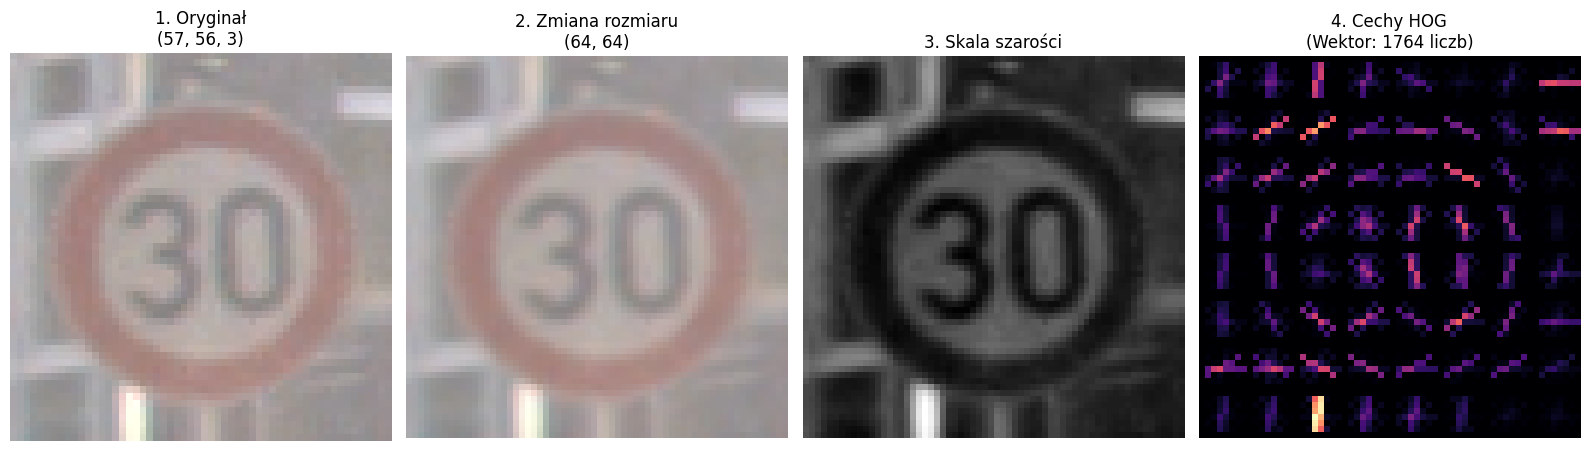

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
import sys

# KONFIGURACJA
IMG_SIZE = (64, 64)
# PODMIEŃ ŚCIEŻKĘ na swoje zdjęcie testowe
image_path = '../data/test_images/trening.jpg' 

def visualize_and_print_all_hog(img_path):
    # 1. Wczytanie oryginalnego obrazu
    img = cv2.imread(img_path)
    if img is None:
        print(f"Błąd: Nie znaleziono obrazu pod ścieżką: {img_path}")
        return
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Zmiana rozmiaru
    img_resized = cv2.resize(img, IMG_SIZE)
    img_resized_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    # 3. Konwersja do skali szarości
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    # 4. Ekstrakcja cech HOG
    features, hog_image = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2), block_norm='L2-Hys',
                              visualize=True)

    #WYŚWIETLANIE WARTOŚCI W KONSOLI
    np.set_printoptions(threshold=sys.maxsize, linewidth=120)

    print(f"Całkowita liczba wygenerowanych cech: {len(features)}\n")
    
    print("Wszystkie wartości wektora:")
    print(np.round(features, 4)) 
    
    print("\nStatystyki wektora:")
    print(f"Najmniejsza wartość: {np.min(features):.4f}")
    print(f"Największa wartość:  {np.max(features):.4f}")
    print(f"Średnia wartość:     {np.mean(features):.4f}")

    #WIZUALIZACJA NA WYKRESIE
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    
    axes[0].imshow(img_rgb)
    axes[0].set_title(f"1. Oryginał\n{img.shape}")
    axes[0].axis('off')

    axes[1].imshow(img_resized_rgb)
    axes[1].set_title(f"2. Zmiana rozmiaru\n{IMG_SIZE}")
    axes[1].axis('off')

    axes[2].imshow(gray, cmap='gray')
    axes[2].set_title("3. Skala szarości")
    axes[2].axis('off')

    axes[3].imshow(hog_image, cmap='magma') 
    axes[3].set_title(f"4. Cechy HOG\n(Wektor: {len(features)} liczb)")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

# Uruchomienie funkcji
visualize_and_print_all_hog(image_path)